In [27]:
# Imports

import os
import re
import langid

os.environ["TRANSFORMERS_CACHE"] = "/hpc/home/bfa6/work/llms/.cache"
os.environ["HF_HOME"] = "/hpc/home/bfa6/work/llms/.cache"

import time
import json
from bert_score import score as bert_score
from unsloth import FastLanguageModel
import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from dotenv import dotenv_values
from tqdm import tqdm
import asyncio
from tqdm.asyncio import tqdm_asyncio
from google import genai
import random
from datasets import Dataset
from trl import SFTTrainer, SFTConfig
from transformers import TextStreamer
import vllm
import nltk
from matplotlib import pyplot as plt
from scipy import stats

config = dotenv_values("../.env")

# Load the model

In [2]:
max_seq_length = 2048 # Can increase for longer reasoning traces
lora_rank = 32 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-0.6B",
    cache_dir="/hpc/home/bfa6/work/llms/.cache",
    max_seq_length = max_seq_length,
    load_in_4bit = False, # False for LoRA 16bit
    fast_inference = True, # Enable vLLM fast inference
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.6, # Reduce if out of memory
    # force_download=True
)

INFO 11-19 16:38:01 [vllm_utils.py:700] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2025.11.2: Fast Qwen3 patching. Transformers: 4.56.2. vLLM: 0.11.0.
   \\   /|    NVIDIA RTX A5000. Num GPUs = 1. Max memory: 23.547 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/Qwen3-0.6B with actual GPU utilization = 59.38%
Unsloth: Your GPU has CUDA compute capability 8.6 with VRAM = 23.55 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 2048. Num Sequences = 256.
Unsloth: vLLM's KV Cache can use up to 13.0 GB. Also swap space = 6 GB.
Unsloth: Not an error, but `device` is not supported in vLLM. Skipping.
INFO 11-19 16:38:03 [utils.py:233] non-default args: {'dt

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 11-19 16:38:04 [model.py:1510] Using max model len 2048
INFO 11-19 16:38:07 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=2048.
WARNING 11-19 16:38:07 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.
INFO 11-19 16:38:08 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='unsloth/Qwen3-0.6B', speculative_config=None, tokenizer='unsloth/Qwen3-0.6B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 11-19 16:38:13 [default_loader.py:267] Loading weights took 2.38 seconds
INFO 11-19 16:38:13 [punica_selector.py:19] Using PunicaWrapperGPU.
INFO 11-19 16:38:14 [gpu_model_runner.py:2653] Model loading took 1.1649 GiB and 3.343225 seconds
INFO 11-19 16:38:22 [backends.py:548] Using cache directory: /hpc/home/bfa6/.cache/vllm/torch_compile_cache/f2c9b32d07/rank_0_0/backbone for vLLM's torch.compile
INFO 11-19 16:38:22 [backends.py:559] Dynamo bytecode transform time: 8.04 s


...

INFO 11-19 16:39:09 [backends.py:218] Compiling a graph for dynamic shape takes 46.11 s


INFO 11-19 16:39:26 [monitor.py:34] torch.compile takes 54.15 s in total
INFO 11-19 16:39:28 [gpu_worker.py:298] Available KV cache memory: 11.39 GiB
INFO 11-19 16:39:28 [kv_cache_utils.py:1087] GPU KV cache size: 106,608 tokens
INFO 11-19 16:39:28 [kv_cache_utils.py:1091] Maximum concurrency for 2,048 tokens per request: 52.05x
INFO 11-19 16:39:28 [vllm_utils.py:705] Unsloth: Running patched vLLM v1 `capture_model`.


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 67/67 [00:20<00:00,  3.34it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:03<00:00,  9.40it/s]

INFO 11-19 16:39:52 [gpu_model_runner.py:3480] Graph capturing finished in 24 secs, took 0.92 GiB
INFO 11-19 16:39:52 [vllm_utils.py:712] Unsloth: Patched vLLM v1 graph capture finished in 24 secs.


INFO 11-19 16:39:54 [core.py:210] init engine (profile, create kv cache, warmup model) took 100.13 seconds
INFO 11-19 16:39:54 [llm.py:306] Supported_tasks: ('generate',)
Unsloth: Just some info: will skip parsing ['post_layernorm', 'post_attention_layernorm', 'ffn_norm', 'norm2', 'input_layernorm', 'post_feedforward_layernorm', 'layer_norm1', 'attention_norm', 'k_norm', 'norm1', 'layer_norm2', 'q_norm', 'norm', 'pre_feedforward_layernorm']
Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['post_layernorm', 'post_attention_layernorm', 'ffn_norm', 'norm2', 'cross_attn_post_attention_layernorm', 'input_layernorm', 'post_feedforward_layernorm', 'layer_norm1', 'attention_norm', 'k_norm', 'norm1', 'layer_norm2', 'q_norm', 'cross_attn_input_layernorm', 'norm', 'pre_feedforward_layernorm']


# Create a chat template

In [3]:
system_prompt = (
    "Your goal is to compress the information from the user in as few tokens as necessary and output the compressed version.\n"
    "Translate to different languages to compress the information. For example if the user is speaking English you can compress the information in Chinese and output Chinese\n"
    "Do NOT produce internal chain-of-thought or step-by-step reasoning.\n"
    "Start immediately with the compressed content (no extra preface)."
)

In [4]:
# chat_template = \
#     "{% if messages[0]['role'] == 'system' %}"\
#         "{{ messages[0]['content'] + eos_token }}"\
#         "{% set loop_messages = messages[1:] %}"\
#     "{% else %}"\
#         "{{ '{system_prompt}' + eos_token }}"\
#         "{% set loop_messages = messages %}"\
#     "{% endif %}"\
#     "{% for message in loop_messages %}"\
#         "{% if message['role'] == 'user' %}"\
#             "{{ '<|user|>\\n' + message['content'] + eos_token }}"\
#         "{% elif message['role'] == 'assistant' %}"\
#             "{{ '<|assistant|>\\n' + message['content'] + eos_token }}"\
#         "{% endif %}"\
#     "{% endfor %}"

# # Replace with out specific template:
# chat_template = chat_template\
#     .replace("'{system_prompt}'",   f"'{system_prompt}'")

# from unsloth.chat_templates import qwen3_template
# tokenizer.chat_template = qwen3_template

tokenizer.chat_template


'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0].role == \'system\' %}\n        {{- messages[0].content + \'\\n\\n\' }}\n    {%- endif %}\n    {{- "# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0].role == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0].content + \'<|im_end|>\\n\' }}\n    {%- endif %}\n{%- endif %}\n{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}\n{%- for forward_message 

# Prepare dataset

In [5]:
# load dataset
with open("/hpc/home/bfa6/work/github/yapper/dataset/chunks.json", "r") as f:
    dataset =  json.load(f)


len(dataset)

18914

In [6]:
def clean_whitespace(text: str) -> str:
    # Collapse multiple spaces/tabs into a single space
    text = re.sub(r'[ \t]+', ' ', text)
    # Collapse multiple newlines into a single newline
    text = re.sub(r'\n+', '\n', text)
    # Strip leading/trailing whitespace
    return text.strip()


for data in tqdm(dataset):
    data["chunk"] = clean_whitespace(data["chunk"])

100%|██████████| 18914/18914 [00:02<00:00, 6906.53it/s]


In [7]:
def get_text_len(text: str):
    inp = [{"role":"system", "content": system_prompt}, {"role":"user", "content": text}]
    text = tokenizer.apply_chat_template(
        inp,
        tokenize = False,
        add_generation_prompt=True,
        enable_thinking=False     
    )

    inputs = tokenizer(text, return_tensors = "pt").to("cuda")
    return len(inputs["input_ids"][0])

In [8]:
# Check token lengths
lens = []

for data in tqdm(dataset):
    length = get_text_len(data["chunk"])

    lens.append({"chunk": data["chunk"], "length": length})


df = pd.DataFrame.from_dict(lens)

df

100%|██████████| 18914/18914 [00:37<00:00, 507.69it/s]


,chunk,length
0,THE CAVE OF ELEPHANTA.\n [Illustration: A view...,734
1,“The whole excavation consists of three princi...,716
2,But let us look a little further at the prophe...,696
3,“_Poiet_. I hope we shall have another good da...,662
4,“_Orn_. No such thing. The storm is their elem...,707
...,...,...
18909,"_Cæsar_, 125, 236.\n Camorra, the, 109.\n Capa...",1140
18910,"Darwin, 224.\n Daumer, Dr, 72.\n Decision, the...",1287
18911,"Habit, of prompt obedience, 20;\n in physical ...",1325
18912,"Padua, the Arena Chapel, 132.\n Parents, the e...",1406


In [9]:
df = df[df["length"] <= 1000]
df

,chunk,length
0,THE CAVE OF ELEPHANTA.\n [Illustration: A view...,734
1,“The whole excavation consists of three princi...,716
2,But let us look a little further at the prophe...,696
3,“_Poiet_. I hope we shall have another good da...,662
4,“_Orn_. No such thing. The storm is their elem...,707
...,...,...
18904,LESSON.\n_Passage chosen_: LE CORBEAU.\n“Augus...,921
18905,MAP QUESTIONS.\nFrom the _Geographical Readers...,759
18906,LESSON.\n_Step 1._—Get the pupils to describe ...,780
18907,OBJECTS.\n1. To give the girls some idea of co...,755


In [10]:
cleaned_dataset = [{"chunk": chunk} for chunk in df["chunk"].to_list()]
random.Random(42).shuffle(cleaned_dataset)  # reproducible shuffle

n_total = len(cleaned_dataset)

# 80:10:10 split
n_train = int(0.8 * n_total)
n_eval  = int(0.1 * n_total)
n_test  = n_total - n_train - n_eval  # ensures all items are used

train_dataset = cleaned_dataset[:n_train]
eval_dataset  = cleaned_dataset[n_train:n_train + n_eval]
test_dataset  = cleaned_dataset[n_train + n_eval:]

print(len(train_dataset), len(eval_dataset), len(test_dataset))
print(f"Total: {n_total}")

14740 1842 1843
Total: 18425


# GRPO

## Reconstruction

In [11]:
decoding_system_prompt = (
    "You are given compressed text generated by another model, which may be in a different language.\n"
    "Your goal is to accurately reconstruct the original uncompressed text IN ENGLISH.\n"
    "Do NOT include any reasoning or commentary — only output the reconstructed text in ENGLISH."
)

In [12]:
def recontruct_input(output):

    messages = [
        {"role": "system", "content": decoding_system_prompt},
        {"role": "user", "content": output}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize = False,
        add_generation_prompt=True,
        enable_thinking=False     
    )

    inputs = tokenizer(text, return_tensors = "pt").to("cuda")

    resp = model.generate(
        **inputs,
        temperature = 0.7,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens = 2048,
    )

    reconstructed_tokens = resp[:, inputs["input_ids"].shape[1]:]

    reconstructed_text = tokenizer.decode(reconstructed_tokens[0], skip_special_tokens=True)

    return reconstructed_text

## Reward formulation

In [13]:
def get_num_tokens(text: str):
    chunk_tokens = tokenizer(text)
    return float(len(chunk_tokens["input_ids"]))

def get_bertscore(original, reconstructed, model_type='bert-base-uncased'):

    P, R, F1 = bert_score([reconstructed], [original], model_type=model_type, verbose=False)

    return float(F1.mean()) - 1

def get_bleu_score(original, reconstructed):
    hypothesis = reconstructed.split()
    reference = original.split()
    
    BLEUscore = nltk.translate.bleu_score.sentence_bleu([reference], hypothesis)
    return BLEUscore - 1

def get_length_reward(original, compressed):
    len_original = get_num_tokens(original)
    len_compressed = get_num_tokens(compressed)

    r = (len_original - len_compressed) * (1/len_original)

    return r
    

def get_multilingual_reward(text, target_langs=None):
    """
    Rewards the model for using non-English words.
    
    Args:
        text (str): The text to analyze.
        target_langs (list, optional): Specific languages to reward (e.g., ['es', 'fr', 'zh']).
                                       If None, any non-English language counts.
    Returns:
        float: Reward in [-1, 1], where 1 = fully non-English, 0 = all English.
    """
    # Tokenize text into words (basic)
    words = re.findall(r'\b\w+\b', text)
    if not words:
        return 0.0

    non_en_count = 0
    total_count = len(words)

    for w in words:
        lang, _ = langid.classify(w)
        if lang != 'en':
            if target_langs is None or lang in target_langs:
                non_en_count += 1

    # Proportion of non-English words
    ratio = non_en_count / total_count

    # Map to reward range [-1, 1]
    reward = np.clip(ratio * 2 - 1, -1, 1)

    return reward

def calculate_rewards(prompts, completions, alpha: float = 0.90, **kwargs):
    chunk = prompts[0][-1]["content"]
    responses = [completion[0]["content"] for completion in completions]

    rewards = []

    for response in responses:
        # First calculate r_len
        r_len = get_length_reward(chunk, response)

        # Now reconstruct input
        reconstructed = recontruct_input(response)

        # r_bleu = get_bleu_score(chunk ,reconstructed)

        r_bert = get_bertscore(chunk ,reconstructed)

        r_multi = get_multilingual_reward(response)

        r_final = alpha * r_bert + (1 - alpha) * r_len + 0.3 * r_multi


        rewards.append(r_final)

    return rewards



# Test Model

In [14]:
from peft import PeftModel
model = PeftModel.from_pretrained(model, "/hpc/home/bfa6/work/github/yapper/results/experiment_0/test1/output/checkpoint-100")

In [15]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 1024, padding_idx=151654)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1024, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [16]:
def compress_text(text, temperature=0.7, max_tokens=2048):
    """Compress a given text using the trained model."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}
    ]
    
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        temperature=temperature,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens=max_tokens,
        streamer=TextStreamer(tokenizer, skip_prompt=True),
    )
    
    output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
    compressed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    return compressed, len(inputs["input_ids"][0]), len(output_tokens[0])

In [17]:
test_sample = test_dataset[1]["chunk"]
test_sample

'"It is a town, lad; the people were anxious enough to have it made into\none, thinking they would have more privileges, but all they seem to\nhave gained is having to pay heavier taxes and support a Burgomaster,\nto whom they give a regular annual income."\n"There is more to be seen and learnt in a town than in our tiny\nvillage, or among these fir-trees," said Hans.\n"Perhaps for you, but not for me. I spent some of my early years at\nLeipzie, yet I was glad when my father accepted the post of head\nforester, and we came to our quiet little village for the winter, and\nlived in the forest during the fine weather."\n"But then, father, you had good reason to be glad; you have often told\nme about your early life."\n"Yes, lad; I never grow weary of telling you how I learnt to know the\nLord. I was a stranger to Him before, and so was your grandfather.\nYour mother first taught us there was a better world to live for than\nthis. But I needed sorrow to make me think. It was on the day tha

In [18]:
# Test on a sample from test set
test_sample = test_dataset[120]["chunk"]

print("="*80)
print("ORIGINAL TEXT:")
print("="*80)
print(test_sample)
print("\n" + "="*80)
print("COMPRESSED OUTPUT:")
print("="*80)

compressed, input_len, output_len = compress_text(test_sample)

print("\n" + "="*80)
print(f"Original tokens: {input_len}")
print(f"Compressed tokens: {output_len}")
print(f"Compression ratio: {output_len/input_len:.2%}")
print(f"Token reduction: {input_len - output_len} tokens ({(1 - output_len/input_len)*100:.1f}% reduction)")


ORIGINAL TEXT:
I sought Major Ingham, whom I found reclining his length in an
easy-chair on the verandah. Not hearing the righteous condemnation I had
hoped he would express, and surprised at his want of feeling, I hotly
protested against the cruelty of the overseer in attacking a man while
all his strength was needed to preserve others from peril, and declaimed
against him for using a whip in proximity to my ears, which made the
Major smile compassionately at my inexperience in such matters. This was
too much for my patience, and I then and there announced my intention to
seek the hospitality of Mr. Waring, his neighbour, as I could
not be any longer the guest of a man who received my complaint so
unsympathetically. On hearing me say this, Mrs. Ingham came out of the
house, and expressed so much concern at this sudden rupture of our
relations that I regretted having been so hasty, and the Major tried to
explain how planters were compelled to leave field-work in charge of
their oversee

In [19]:
def reconstruct_text(compressed_text, max_tokens=784):
    """Reconstruct original text from compressed version."""
    messages = [
        {"role": "system", "content": decoding_system_prompt},
        {"role": "user", "content": compressed_text}
    ]
    
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        temperature=0.7,
        top_p=0.8,
        top_k=20,
        min_p=0.0,
        max_new_tokens=max_tokens,
    )
    
    output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
    reconstructed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    return reconstructed

In [20]:
# Reconstruct from compressed
print("="*80)
print("RECONSTRUCTED TEXT:")
print("="*80)

reconstructed = reconstruct_text(compressed)
print(reconstructed)
print("len = ", len(reconstructed.split()))

print("\n" + "="*80)
print("QUALITY METRICS:")
print("="*80)

# Calculate BLEU score
bert = get_bertscore(test_sample, reconstructed)
print(f"RECONSTRUCTION Score: {bert + 1:.4f}")  # Add 1 back since we subtracted it in reward

# Calculate compression reward
compression_reward = get_length_reward(test_sample, compressed)
print(f"Compression Reward: {compression_reward:.4f}")

# Multilingual reward:
r_multi = get_multilingual_reward(compressed)

# Calculate final reward (as used in training)
alpha = 0.90
final_reward = alpha * bert + (1 - alpha) * compression_reward + 0.3 * r_multi
print(f"Final Reward (alpha={alpha}): {final_reward:.4f}")

RECONSTRUCTED TEXT:
I am seeking the main person, Ingham, who is sitting on an easy chair in the garden bench. I have not heard him expect a just trial and have been surprised by his lack of emotional response. I strongly oppose him attacking someone and using all his strength to protect others from danger. I condemn him approaching my ear with a whip. Ingham has shown me his lack of skill in this matter and has been deeply sorry for it. This has exceeded my patience, so I have asked Mr. Waring for his help. When he spoke, Ingham left home and expressed his concern about the sudden breakup of this relationship. I felt regret. Ingham tried to explain that the employee had been forced to transfer the land to his employee, but it was too late. Words made me feel pain, and personal dignity was damaged. Ingham did not handle this wound properly, and I remained true to my original intention. After half an hour, I brought some letters and documents home and walked to Mr. Waring's farm. We hav

In [21]:
def evaluate_test_set(test_data, num_samples=100):
    """Evaluate model on multiple test samples."""
    results = []
    
    for i, sample in enumerate(tqdm(test_data[:num_samples], desc="Evaluating")):
        original = sample["chunk"]
        
        # Compress
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": original}
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                temperature=0.7,
                top_p=0.8,
                top_k=20,
                max_new_tokens=2048,
            )
        
        output_tokens = outputs[:, inputs["input_ids"].shape[1]:]
        compressed = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
        
        # Reconstruct
        reconstructed = reconstruct_text(compressed)
        
        # Calculate metrics
        orig_len = get_num_tokens(original)
        comp_len = get_num_tokens(compressed)
        bert = get_bertscore(original, reconstructed)
        comp_ratio = comp_len / orig_len
        multilang_reward = get_multilingual_reward(compressed)
        
        results.append({
            "original_tokens": orig_len,
            "compressed_tokens": comp_len,
            "compression_ratio": comp_ratio,
            "bert_score": bert + 1,  # Add back the -1
            "sample_idx": i,
            "multilingual": multilang_reward
        })
    
    return pd.DataFrame(results)

In [23]:
eval_results = evaluate_test_set(eval_dataset, num_samples=10)

Evaluating: 100%|██████████| 10/10 [04:30<00:00, 27.08s/it]


In [24]:
print("="*80)
print("TEST SET EVALUATION SUMMARY")
print("="*80)
print(f"\nNumber of samples: {len(eval_results)}")
print(f"\nAverage compression ratio: {eval_results['compression_ratio'].mean():.2%}")
print(f"Median compression ratio: {eval_results['compression_ratio'].median():.2%}")
print(f"Std compression ratio: {eval_results['compression_ratio'].std():.4f}")
print(f"\nAverage BERT score: {eval_results['bert_score'].mean():.4f}")
print(f"Median BERT score: {eval_results['bert_score'].median():.4f}")
print(f"Std BERT score: {eval_results['bert_score'].std():.4f}")
print(f"\nAverage Multilang score: {eval_results['multilingual'].mean():.4f}")
print(f"Median Multilang score: {eval_results['multilingual'].median():.4f}")
print(f"Std Multilang score: {eval_results['multilingual'].std():.4f}")
print(f"\nAverage token reduction: {(eval_results['original_tokens'] - eval_results['compressed_tokens']).mean():.1f} tokens")
print(f"Total tokens saved: {(eval_results['original_tokens'] - eval_results['compressed_tokens']).sum():.0f} tokens")

TEST SET EVALUATION SUMMARY

Number of samples: 10

Average compression ratio: 63.39%
Median compression ratio: 61.41%
Std compression ratio: 0.1887

Average BERT score: 0.6927
Median BERT score: 0.6593
Std BERT score: 0.1138

Average Multilang score: 0.4434
Median Multilang score: 0.8399
Std Multilang score: 0.7348

Average token reduction: 226.5 tokens
Total tokens saved: 2265 tokens


Linear fit r^2 = 0.4879, p = 0.0246


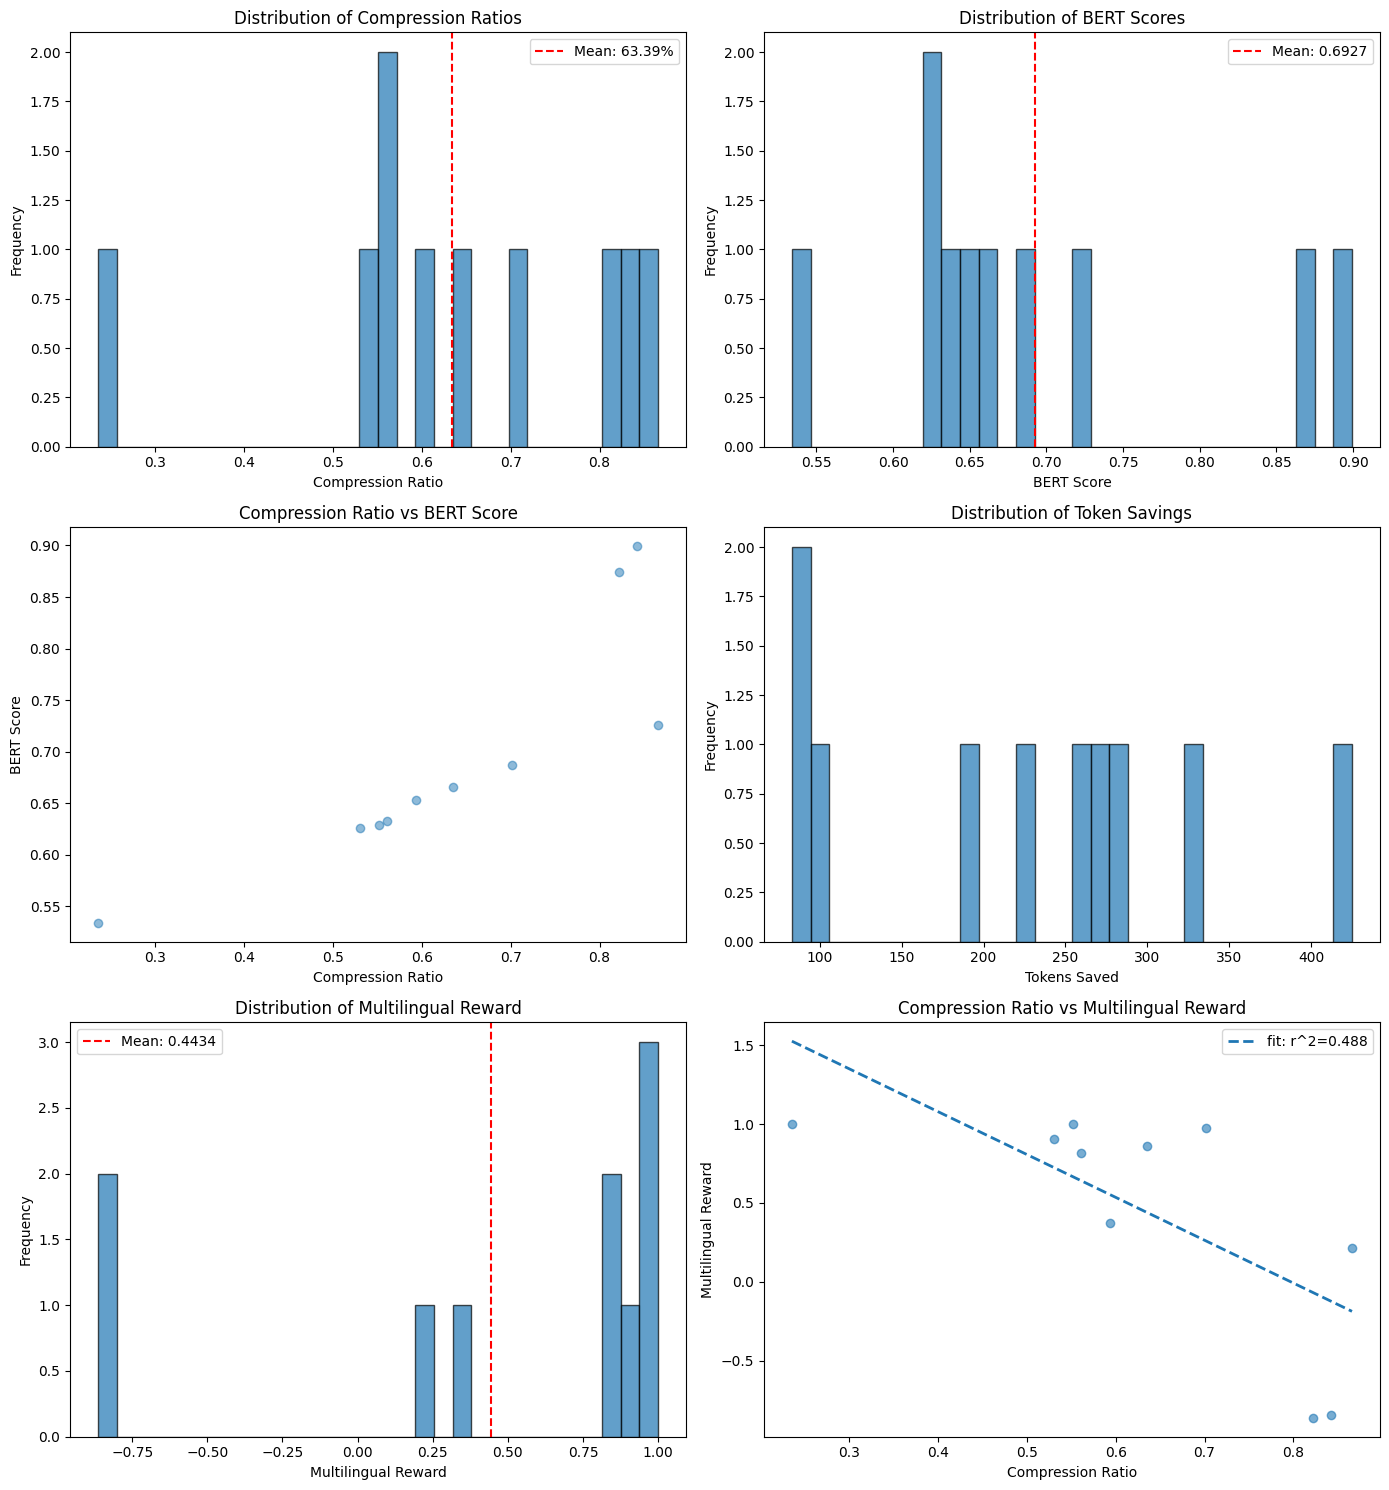

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Row 0 Col 0: Compression ratio distribution
axes[0, 0].hist(eval_results['compression_ratio'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Compression Ratio')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Compression Ratios')
axes[0, 0].axvline(eval_results['compression_ratio'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["compression_ratio"].mean():.2%}')
axes[0, 0].legend()

# Row 0 Col 1: BERT score distribution (kept)
axes[0, 1].hist(eval_results['bert_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('BERT Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of BERT Scores')
axes[0, 1].axvline(eval_results['bert_score'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["bert_score"].mean():.4f}')
axes[0, 1].legend()

# Row 1 Col 0: Compression vs BERT scatter (fixed label)
axes[1, 0].scatter(eval_results['compression_ratio'], eval_results['bert_score'], alpha=0.5)
axes[1, 0].set_xlabel('Compression Ratio')
axes[1, 0].set_ylabel('BERT Score')    # fixed label (was BLEU)
axes[1, 0].set_title('Compression Ratio vs BERT Score')

# Row 1 Col 1: Token reduction
axes[1, 1].hist(eval_results['original_tokens'] - eval_results['compressed_tokens'],
                bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Tokens Saved')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Token Savings')

# Row 2 Col 0: Multilingual reward distribution
axes[2, 0].hist(eval_results['multilingual'], bins=30, edgecolor='black', alpha=0.7)
axes[2, 0].set_xlabel('Multilingual Reward')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Distribution of Multilingual Reward')
axes[2, 0].axvline(eval_results['multilingual'].mean(), color='red', linestyle='--',
                   label=f'Mean: {eval_results["multilingual"].mean():.4f}')
axes[2, 0].legend()

# Row 2 Col 1: Compression ratio vs Multilingual reward (scatter + linear fit)
x = eval_results['compression_ratio'].to_numpy()
y = eval_results['multilingual'].to_numpy()
axes[2, 1].scatter(x, y, alpha=0.6)
axes[2, 1].set_xlabel('Compression Ratio')
axes[2, 1].set_ylabel('Multilingual Reward')
axes[2, 1].set_title('Compression Ratio vs Multilingual Reward')

if len(x) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    fit_x = np.linspace(x.min(), x.max(), 100)
    fit_y = slope * fit_x + intercept
    axes[2, 1].plot(fit_x, fit_y, linestyle='--', linewidth=2, label=f'fit: r^2={r_value**2:.3f}')
    axes[2, 1].legend()
    print(f"Linear fit r^2 = {r_value**2:.4f}, p = {p_value:.3g}")
else:
    print("Not enough points to compute regression.")

plt.tight_layout()
plt.show()


In [ ]:
# Save detailed results
eval_results.to_csv('/hpc/home/bfa6/work/github/yapper/results/test/test_results.csv', index=False)
print("Results saved to test_results.csv")

In [35]:
# Find best and worst samples
best_idx = eval_results.sort_values('bleu_score', ascending=False).iloc[0]['sample_idx']
worst_idx = eval_results.sort_values('bleu_score', ascending=True).iloc[0]['sample_idx']

print("="*80)
print("BEST COMPRESSION (Highest BLEU)")
print("="*80)
print(f"\nOriginal:\n{test_dataset[int(best_idx)]['chunk'][:500]}...")
compressed_best, _, _ = compress_text(test_dataset[int(best_idx)]['chunk'])
print(f"\nCompressed:\n{compressed_best[:500]}...")
print(f"\nBLEU: {eval_results.iloc[int(best_idx)]['bleu_score']:.4f}")
print(f"Compression: {eval_results.iloc[int(best_idx)]['compression_ratio']:.2%}")

print("\n" + "="*80)
print("WORST COMPRESSION (Lowest BLEU)")
print("="*80)
print(f"\nOriginal:\n{test_dataset[int(worst_idx)]['chunk'][:500]}...")
compressed_worst, _, _ = compress_text(test_dataset[int(worst_idx)]['chunk'])
print(f"\nCompressed:\n{compressed_worst[:500]}...")
print(f"\nBLEU: {eval_results.iloc[int(worst_idx)]['bleu_score']:.4f}")
print(f"Compression: {eval_results.iloc[int(worst_idx)]['compression_ratio']:.2%}")

BEST COMPRESSION (Highest BLEU)

Original:
It was most likely on a visit of expostulation, or as spies, that the
Mationa chiefs had been to Wesley Vale; but as no interpreter could be
found, the interview ended in nothing but an exchange of presents. I
heard that there was a woman born among the Mationa, but now naturalised
in Amiral’s tribe; and I sent messengers long distances to try and bring
her, but she was not to be found—only her two half-caste children, who
knew nothing but Hottentot.
The country appeared to have become quite dev...
It was likely on a visit of expostulation or as spies that the Mationa chiefs had been to Wesley Vale; but no interpreter was found, so the interview ended in exchange of presents. I heard of a woman born among the Mationa, now naturalised in Amiral’s tribe; I sent messengers long distances to bring her, but she was not found—only her two half-caste children, who knew nothing but Hottentot. The country appeared to have become devoid of landmarks, on